# Milestone 4 — CRNN

In [23]:
!pip install wandb -q

In [24]:
import os, random, time, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchaudio.transforms as T
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import wandb

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [25]:
# CONFIG

SR, DURATION  = 22050, 5
SAMPLES       = SR * DURATION
N_MELS        = 128
N_FFT         = 2048
HOP_LENGTH    = 512
FMIN, FMAX    = 20, 8000
SPEC_W        = (SAMPLES // HOP_LENGTH) + 1   

BATCH_SIZE    = 64
NUM_EPOCHS    = 40
LR            = 1e-3
WD            = 2e-4
DROPOUT       = 0.5
NUM_CLASSES   = 10
NUM_WORKERS   = 2

GRU_HIDDEN    = 128
GRU_LAYERS    = 1
GRU_OUT       = GRU_HIDDEN * 2   
GRU_T         = SPEC_W // 16     


N_AUG         = 12   
N_VAL         = 200   
NOISE_MIN     = 0.05
NOISE_MAX     = 0.35
N_TTA         = 10

M3_VAL_F1     = 0.8401
M3_LB         = 0.80789

GENRES = sorted(['blues','classical','country','disco','hiphop',
                 'jazz','metal','pop','reggae','rock'])
G2I = {g:i for i,g in enumerate(GENRES)}
I2G = {i:g for g,i in G2I.items()}

BASE = None
for p in ['/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup',
          '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup']:
    if os.path.exists(p): BASE = p; break
assert BASE

GENRES_PATH   = f'{BASE}/genres_stems'
NOISE_PATH    = f'{BASE}/ESC-50-master/audio'
MASHUPS_PATH  = f'{BASE}/mashups'
TEST_CSV      = f'{BASE}/test.csv'

print(f'Dataset: {BASE}')
print(f'GRU: hidden={GRU_HIDDEN}×2={GRU_OUT}, layers={GRU_LAYERS}, steps={GRU_T}')
print(f'Train: ~{850*N_AUG} samples | Val: {len(GENRES)*N_VAL} samples')

Dataset: /kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup
GRU: hidden=128×2=256, layers=1, steps=13
Train: ~10200 samples | Val: 2000 samples


In [26]:
# CATALOG + SPLIT

catalog = {}
for g in GENRES:
    gdir = f'{GENRES_PATH}/{g}'
    songs = sorted([f'{gdir}/{s}' for s in os.listdir(gdir)
                    if os.path.isdir(f'{gdir}/{s}')])
    catalog[g] = songs
    print(f'  {g:12s}: {len(songs)} songs')

STEMS = [f for f in os.listdir(catalog[GENRES[0]][0]) if f.endswith('.wav')]
print(f'Stems: {STEMS}')
noise_files = [f'{NOISE_PATH}/{f}' for f in os.listdir(NOISE_PATH) if f.endswith('.wav')]
print(f'Noise files: {len(noise_files)}')

rng = random.Random(SEED)
tr_songs, vl_songs = {}, {}
for g, songs in catalog.items():
    s = songs.copy(); rng.shuffle(s)
    n = max(2, int(len(s)*0.15))
    vl_songs[g] = s[:n]; tr_songs[g] = s[n:]
print('Split:', {g: f'{len(tr_songs[g])}tr/{len(vl_songs[g])}vl' for g in GENRES})

  blues       : 100 songs
  classical   : 100 songs
  country     : 100 songs
  disco       : 100 songs
  hiphop      : 100 songs
  jazz        : 100 songs
  metal       : 100 songs
  pop         : 100 songs
  reggae      : 100 songs
  rock        : 100 songs
Stems: ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']
Noise files: 2000
Split: {'blues': '85tr/15vl', 'classical': '85tr/15vl', 'country': '85tr/15vl', 'disco': '85tr/15vl', 'hiphop': '85tr/15vl', 'jazz': '85tr/15vl', 'metal': '85tr/15vl', 'pop': '85tr/15vl', 'reggae': '85tr/15vl', 'rock': '85tr/15vl'}


In [27]:
# AUDIO HELPERS

def load_stem(path):
    try:
        y, _ = librosa.load(path, sr=SR, mono=True, duration=DURATION+2)
        if len(y) < SAMPLES: y = np.pad(y, (0, SAMPLES-len(y)))
        else:
            s = random.randint(0, len(y)-SAMPLES); y = y[s:s+SAMPLES]
        return y.astype(np.float32)
    except: return np.zeros(SAMPLES, np.float32)

def load_noise():
    try:
        y, _ = librosa.load(random.choice(noise_files), sr=SR, mono=True)
        if len(y) < SAMPLES: y = np.tile(y, (SAMPLES//len(y))+1)
        s = random.randint(0, len(y)-SAMPLES)
        return y[s:s+SAMPLES].astype(np.float32)
    except: return np.zeros(SAMPLES, np.float32)

def make_mashup(genre, song_pool):
    songs = random.choices(song_pool[genre], k=4)
    stems = STEMS.copy(); random.shuffle(stems)
    mixed = np.zeros(SAMPLES, np.float32)
    for song, stem in zip(songs, stems[:4]):
        y = load_stem(f'{song}/{stem}')
        mx = np.max(np.abs(y))
        if mx > 0: y /= (mx + 1e-6)
        mixed += random.uniform(0.4, 1.0) * y
    mx = np.max(np.abs(mixed))
    if mx > 0: mixed /= (mx + 1e-6)
    noise = load_noise()
    mixed += random.uniform(NOISE_MIN, NOISE_MAX) * noise
    mx = np.max(np.abs(mixed))
    if mx > 0: mixed /= (mx + 1e-6)
    return mixed

def to_spec(y):
    mel = librosa.feature.melspectrogram(
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP_LENGTH,
        n_mels=N_MELS, fmin=FMIN, fmax=FMAX)
    mel = librosa.power_to_db(mel, ref=np.max)
    mel = (mel - mel.min()) / (mel.max() - mel.min() + 1e-9)
    if mel.shape[1] < SPEC_W: mel = np.pad(mel, ((0,0),(0,SPEC_W-mel.shape[1])))
    return mel[:, :SPEC_W].astype(np.float32)

print('Audio helpers ready.')

Audio helpers ready.


In [28]:
# PRE-COMPUTE SPECTROGRAMS

n_tr = sum(len(v) for v in tr_songs.values()) * N_AUG
n_vl = len(GENRES) * N_VAL
print(f'Pre-computing {n_tr} train + {n_vl} val spectrograms...')
X_tr, y_tr, X_vl, y_vl = [], [], [], []
t0 = time.time()

for g in GENRES:
    lbl = G2I[g]
    for _ in tqdm(range(len(tr_songs[g]) * N_AUG), desc=f'TR {g}', leave=False):
        X_tr.append(to_spec(make_mashup(g, tr_songs))); y_tr.append(lbl)
    for _ in tqdm(range(N_VAL), desc=f'VL {g}', leave=False):
        X_vl.append(to_spec(make_mashup(g, vl_songs))); y_vl.append(lbl)

X_tr = np.array(X_tr, np.float32); y_tr = np.array(y_tr, np.int64)
X_vl = np.array(X_vl, np.float32); y_vl = np.array(y_vl, np.int64)
print(f'Done in {(time.time()-t0)/60:.1f} min')
print(f'X_tr: {X_tr.shape} ({X_tr.nbytes/1e6:.0f}MB) | X_vl: {X_vl.shape} ({X_vl.nbytes/1e6:.0f}MB)')
print(f'Train: {np.bincount(y_tr)} | Val: {np.bincount(y_vl)}')

Pre-computing 10200 train + 2000 val spectrograms...


Done in 20.1 min
X_tr: (10200, 128, 216) (1128MB) | X_vl: (2000, 128, 216) (221MB)
Train: [1020 1020 1020 1020 1020 1020 1020 1020 1020 1020] | Val: [200 200 200 200 200 200 200 200 200 200]


In [29]:
# DATASET

class SpecDS(Dataset):
    def __init__(self, X, y, aug=False):
        self.X  = torch.tensor(X).unsqueeze(1)
        self.y  = torch.tensor(y)
        self.aug = aug
        self.fm = T.FrequencyMasking(freq_mask_param=20)
        self.tm = T.TimeMasking(time_mask_param=40)
    def __len__(self): return len(self.y)
    def __getitem__(self, i):
        x = self.X[i].clone()
        if self.aug:
            if random.random() > 0.4: x = self.fm(x)
            if random.random() > 0.4: x = self.tm(x)
        return x, self.y[i]

tr_ds = SpecDS(X_tr, y_tr, aug=True)
vl_ds = SpecDS(X_vl, y_vl, aug=False)
tr_dl = DataLoader(tr_ds, BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
vl_dl = DataLoader(vl_ds, BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
print(f'Train: {len(tr_ds)} samples | Val: {len(vl_ds)} samples')
print(f'Val per class: {len(vl_ds)//10} (was 50 → now {N_VAL} → stable F1)')

Train: 10200 samples | Val: 2000 samples
Val per class: 200 (was 50 → now 200 → stable F1)


In [30]:
# CRNN MODEL


class ConvBlock(nn.Module):
    def __init__(self, ic, oc, pool=True):
        super().__init__()
        layers = [
            nn.Conv2d(ic, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
            nn.Conv2d(oc, oc, 3, padding=1, bias=False),
            nn.BatchNorm2d(oc), nn.ReLU(inplace=True),
        ]
        if pool: layers.append(nn.MaxPool2d(2, 2))
        self.b = nn.Sequential(*layers)
    def forward(self, x): return self.b(x)


class AttentionPool(nn.Module):
    """Learns which of the 13 time steps contain the most genre info."""
    def __init__(self, h):
        super().__init__()
        self.w = nn.Linear(h, 1)
    def forward(self, x):                             
        w = F.softmax(self.w(x).squeeze(-1), dim=1)   
        return (x * w.unsqueeze(-1)).sum(dim=1)       


class CRNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            ConvBlock(1,   32,  pool=True),  
            ConvBlock(32,  64,  pool=True),   
            ConvBlock(64,  128, pool=True),   
            ConvBlock(128, 256, pool=True),  
            ConvBlock(256, 256, pool=False),  
        )

        self.freq_pool = nn.AdaptiveAvgPool2d((1, None))

        self.gru = nn.GRU(
            input_size    = 256,
            hidden_size   = GRU_HIDDEN,   
            num_layers    = GRU_LAYERS,  
            batch_first   = True,
            bidirectional = True,         
        )

        self.attn = AttentionPool(GRU_OUT)   

        self.head = nn.Sequential(
            nn.LayerNorm(GRU_OUT),
            nn.Linear(GRU_OUT, 256), nn.ReLU(inplace=True), nn.Dropout(DROPOUT),
            nn.Linear(256, 128),     nn.ReLU(inplace=True), nn.Dropout(DROPOUT/2),
            nn.Linear(128, NUM_CLASSES)
        )

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1); nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.constant_(m.bias, 0)

    def forward(self, x):            
        x = self.cnn(x)             
        x = self.freq_pool(x)       
        x = x.squeeze(2)            
        x = x.permute(0, 2, 1)      
        x, _ = self.gru(x)         
        x = self.attn(x)             
        return self.head(x)          


model = CRNN().to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
cnn_p   = sum(p.numel() for p in model.cnn.parameters())
gru_p   = sum(p.numel() for p in model.gru.parameters())
print(f'Parameters: {total_p:,}  (CNN: {cnn_p:,} | GRU: {gru_p:,})')
print(f'Previous run had GRU params: ~{3*(256*256*3 + 256*256 + 256*3):,} (3x more)')


print('\nShape trace:')
with torch.no_grad():
    d = torch.randn(2,1,N_MELS,SPEC_W).to(DEVICE)
    print(f'  Input:      {tuple(d.shape)}')
    t = model.cnn(d)
    print(f'  After CNN:  {tuple(t.shape)}  ← (B,256,8,13)')
    t = model.freq_pool(t).squeeze(2).permute(0,2,1)
    print(f'  GRU input:  {tuple(t.shape)}  ← (B,13,256)')
    t, _ = model.gru(t)
    print(f'  GRU output: {tuple(t.shape)}  ← (B,13,256) [128×2 bidir]')
    out = model(d)
    print(f'  Output:     {tuple(out.shape)}  ✅')

Parameters: 2,750,507  (CNN: 2,353,312 | GRU: 296,448)
Previous run had GRU params: ~788,736 (3x more)

Shape trace:
  Input:      (2, 1, 128, 216)
  After CNN:  (2, 256, 8, 13)  ← (B,256,8,13)
  GRU input:  (2, 13, 256)  ← (B,13,256)
  GRU output: (2, 13, 256)  ← (B,13,256) [128×2 bidir]
  Output:     (2, 10)  ✅


In [31]:
# LOSS / OPTIMIZER / SCHEDULER

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)
print('CrossEntropyLoss + AdamW + CosineAnnealingLR')

CrossEntropyLoss + AdamW + CosineAnnealingLR


In [32]:
# # W&B

# wandb.login()  
# run = wandb.init(
#     project='genre-classification',  
#     name='milestone4-crnn-model',
#     config=dict(
#         architecture  = 'CRNN',
#         gru_hidden    = GRU_HIDDEN,
#         gru_layers    = GRU_LAYERS,
#         gru_steps     = GRU_T,
#         gru_bidir     = True,
#         attention     = True,
#         epochs        = NUM_EPOCHS,
#         batch_size    = BATCH_SIZE,
#         lr            = LR,
#         weight_decay  = WD,
#         dropout       = DROPOUT,
#         n_aug         = N_AUG,
#         n_val         = N_VAL,
#         n_tta         = N_TTA,
#         m3_ref_val    = M3_VAL_F1,
#         m3_ref_lb     = M3_LB,
#     ),
#     tags=['milestone-4','crnn','bigru','attention']
# )
# print(f'W&B run: {run.url}')

In [33]:
# TRAINING LOOP

def train_ep(model, dl):
    model.train()
    loss_sum, ps, ls = 0.0, [], []
    for x, y in dl:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        loss_sum += loss.item()
        ps.extend(out.argmax(1).cpu().numpy())
        ls.extend(y.cpu().numpy())
    return loss_sum/len(dl), f1_score(ls, ps, average='macro')


@torch.no_grad()
def val_ep(model, dl):
    model.eval()
    loss_sum, ps, ls = 0.0, [], []
    for x, y in dl:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        out = model(x)
        loss_sum += criterion(out, y).item()
        ps.extend(F.softmax(out,1).argmax(1).cpu().numpy())
        ls.extend(y.cpu().numpy())
    return loss_sum/len(dl), f1_score(ls, ps, average='macro'), ps, ls


best_f1, best_ep = 0.0, 0
hist = {k: [] for k in ['tl','tf','vl','vf']}

print('🚀 Training CRNN (M4)!')
print('='*65)
print(f'  GRU: hidden={GRU_HIDDEN}×2, steps={GRU_T}')
print(f'  Val: {len(vl_ds)} samples ({N_VAL}/class) — stable F1')
print(f'  M3 CNN reference: val={M3_VAL_F1}, LB={M3_LB}')
print('='*65)

t_all = time.time()
for ep in range(NUM_EPOCHS):
    t0 = time.time()
    tl, tf = train_ep(model, tr_dl)
    vl, vf, _, _ = val_ep(model, vl_dl)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    for k,v in zip(['tl','tf','vl','vf'],[tl,tf,vl,vf]):
        hist[k].append(v)

    # wandb.log({
    #     'epoch'           : ep+1,
    #     'train/loss'      : tl,
    #     'train/macro_f1'  : tf,
    #     'val/loss'        : vl,
    #     'val/macro_f1'    : vf,
    #     'lr'              : lr,
    #     'train_val_gap'   : tf - vf,        
    #     'vs_m3'           : vf - M3_VAL_F1, 
    # })

    flag = ''
    if vf > best_f1:
        best_f1, best_ep = vf, ep+1
        torch.save({'ep':ep+1,'state':model.state_dict(),'f1':vf}, 'best_crnn_m4.pth')
        flag = ' ✨'

    gap = tf - vf
    print(f'Ep {ep+1:02d}/{NUM_EPOCHS} | '
          f'Tr {tl:.4f}/{tf:.4f} | '
          f'Vl {vl:.4f}/{vf:.4f} | '
          f'Gap {gap:.3f} | '
          f'{time.time()-t0:.0f}s{flag}')

print(f'\n✅ Done in {(time.time()-t_all)/60:.1f} min')
print(f'🏆 Best CRNN Val F1: {best_f1:.4f} (epoch {best_ep})')
print(f'   M3 CNN Val F1:    {M3_VAL_F1:.4f}')
print(f'   Difference:       {best_f1-M3_VAL_F1:+.4f}')

🚀 Training CRNN (M4)!
  GRU: hidden=128×2, steps=13
  Val: 2000 samples (200/class) — stable F1
  M3 CNN reference: val=0.8401, LB=0.80789
Ep 01/40 | Tr 1.9458/0.3253 | Vl 2.4652/0.1320 | Gap 0.193 | 32s ✨
Ep 02/40 | Tr 1.6105/0.4838 | Vl 1.6468/0.4723 | Gap 0.011 | 33s ✨
Ep 03/40 | Tr 1.4316/0.5768 | Vl 1.5881/0.4682 | Gap 0.109 | 33s
Ep 04/40 | Tr 1.3009/0.6481 | Vl 1.7777/0.4266 | Gap 0.222 | 33s
Ep 05/40 | Tr 1.1964/0.7037 | Vl 1.6993/0.4819 | Gap 0.222 | 33s ✨
Ep 06/40 | Tr 1.1034/0.7476 | Vl 1.9403/0.3894 | Gap 0.358 | 33s
Ep 07/40 | Tr 1.0315/0.7916 | Vl 1.3141/0.6265 | Gap 0.165 | 33s ✨
Ep 08/40 | Tr 0.9583/0.8282 | Vl 1.9854/0.3416 | Gap 0.487 | 33s
Ep 09/40 | Tr 0.9046/0.8498 | Vl 2.6108/0.2613 | Gap 0.589 | 33s
Ep 10/40 | Tr 0.8507/0.8757 | Vl 2.1087/0.3655 | Gap 0.510 | 33s
Ep 11/40 | Tr 0.8043/0.8990 | Vl 1.5699/0.5148 | Gap 0.384 | 33s
Ep 12/40 | Tr 0.7706/0.9120 | Vl 1.4219/0.6122 | Gap 0.300 | 33s
Ep 13/40 | Tr 0.7280/0.9291 | Vl 1.3885/0.6226 | Gap 0.307 | 33s
Ep 14/40

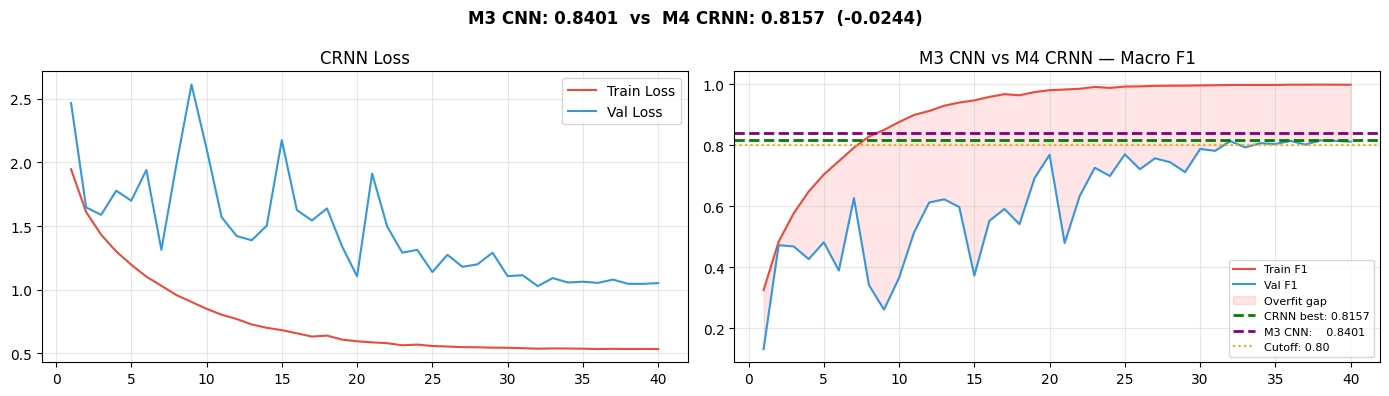

In [34]:
# M3 vs M4 COMPARISON PLOT

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
ep_r = range(1, NUM_EPOCHS+1)

axes[0].plot(ep_r, hist['tl'], label='Train Loss', color='#e74c3c')
axes[0].plot(ep_r, hist['vl'], label='Val Loss',   color='#3498db')
axes[0].set_title('CRNN Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep_r, hist['tf'], label='Train F1', color='#e74c3c')
axes[1].plot(ep_r, hist['vf'], label='Val F1',   color='#3498db')
axes[1].fill_between(ep_r, hist['vf'], hist['tf'],
                     alpha=0.1, color='red', label='Overfit gap')
axes[1].axhline(best_f1,   color='green',  ls='--', lw=2,
                label=f'CRNN best: {best_f1:.4f}')
axes[1].axhline(M3_VAL_F1, color='purple', ls='--', lw=2,
                label=f'M3 CNN:    {M3_VAL_F1:.4f}')
axes[1].axhline(0.80,      color='orange', ls=':',
                label='Cutoff: 0.80')
axes[1].set_title('M3 CNN vs M4 CRNN — Macro F1')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

diff = best_f1 - M3_VAL_F1
plt.suptitle(
    f'M3 CNN: {M3_VAL_F1:.4f}  vs  M4 CRNN: {best_f1:.4f}  '
    f'({"+" if diff>0 else ""}{diff:.4f})',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('m3_vs_m4.png', dpi=100)
plt.show()
# wandb.log({'m3_vs_m4_comparison': wandb.Image('m3_vs_m4.png')})

Best CRNN: epoch 38, val F1=0.8157

=== M3 vs M4 Summary ===
  M3 CNN  — Val F1: 0.8401  LB: 0.80789
  M4 CRNN — Val F1: 0.8157  LB: (submit to find out)
  Difference:       -0.0244

=== Per-Class F1 ===
              precision    recall  f1-score   support

       blues      0.778     0.790     0.784       200
   classical      0.978     0.900     0.938       200
     country      0.750     0.615     0.676       200
       disco      0.732     0.875     0.797       200
      hiphop      0.821     0.920     0.868       200
        jazz      0.860     0.955     0.905       200
       metal      0.949     0.940     0.945       200
         pop      0.824     0.845     0.835       200
      reggae      0.805     0.825     0.815       200
        rock      0.679     0.530     0.596       200

    accuracy                          0.820      2000
   macro avg      0.818     0.820     0.816      2000
weighted avg      0.818     0.820     0.816      2000



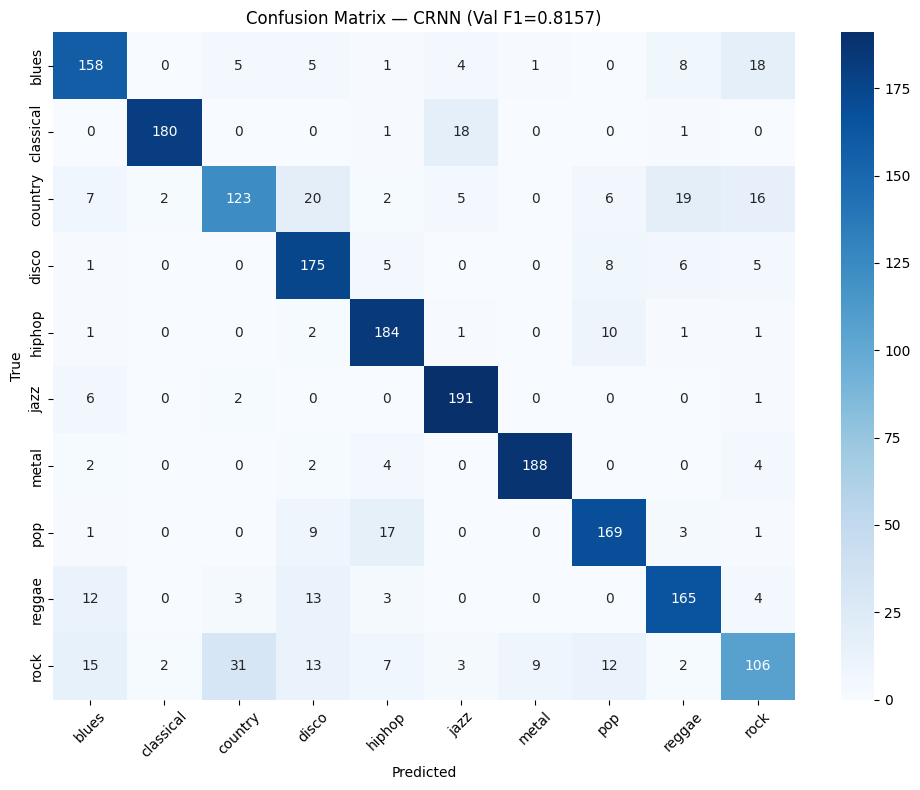

In [35]:
# PER-CLASS REPORT + CONFUSION MATRIX

ckpt = torch.load('best_crnn_m4.pth', map_location=DEVICE)
model.load_state_dict(ckpt['state'])
print(f'Best CRNN: epoch {ckpt["ep"]}, val F1={ckpt["f1"]:.4f}')

_, vf, vp, vl_true = val_ep(model, vl_dl)
print(f'\n=== M3 vs M4 Summary ===')
print(f'  M3 CNN  — Val F1: {M3_VAL_F1:.4f}  LB: {M3_LB:.5f}')
print(f'  M4 CRNN — Val F1: {vf:.4f}  LB: (submit to find out)')
print(f'  Difference:       {vf-M3_VAL_F1:+.4f}')

print('\n=== Per-Class F1 ===')
print(classification_report(vl_true, vp, target_names=GENRES, digits=3))

cm = confusion_matrix(vl_true, vp)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=GENRES, yticklabels=GENRES, cmap='Blues')
plt.title(f'Confusion Matrix — CRNN (Val F1={vf:.4f})')
plt.xticks(rotation=45); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('crnn_cm.png', dpi=100); plt.show()
# wandb.log({'confusion_matrix': wandb.Image('crnn_cm.png'), 'best_val_f1': vf})

In [36]:
# INFERENCE WITH TTA × 10

test_df = pd.read_csv(TEST_CSV)
lookup = {}
for f in os.listdir(MASHUPS_PATH):
    if f.endswith('.wav'):
        num = int(f.replace('song','').replace('.wav',''))
        lookup[num] = f'{MASHUPS_PATH}/{f}'
print(f'Test: {len(test_df)} | Matched: {sum(1 for i in test_df["id"] if int(i) in lookup)}')

model.eval()
all_ids, all_preds = [], []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f'TTA×{N_TTA}'):
    sid = int(row['id'])
    fp  = lookup.get(sid)
    if not fp: all_ids.append(row['id']); all_preds.append('pop'); continue
    try: audio, _ = librosa.load(fp, sr=SR, mono=True)
    except: all_ids.append(row['id']); all_preds.append('pop'); continue

    probs = np.zeros(NUM_CLASSES)
    for _ in range(N_TTA):
        if len(audio) <= SAMPLES: seg = np.pad(audio,(0,SAMPLES-len(audio)))
        else:
            s = random.randint(0,len(audio)-SAMPLES); seg = audio[s:s+SAMPLES]
        t = torch.tensor(to_spec(seg.astype(np.float32))).unsqueeze(0).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            probs += F.softmax(model(t),1).cpu().numpy()[0]
    all_ids.append(row['id'])
    all_preds.append(I2G[np.argmax(probs)])

print(f'Done! {len(all_preds)} predictions')

Test: 3020 | Matched: 3020


TTA×10: 100%|██████████| 3020/3020 [08:14<00:00,  6.11it/s]

Done! 3020 predictions


In [38]:
# SUBMISSION

sub = pd.DataFrame({'id': all_ids, 'genre': all_preds})
assert all(g in set(GENRES) for g in sub['genre'])
assert len(sub) == len(test_df)
sub.to_csv('submission.csv', index=False)
print('Prediction distribution:')
print(sub['genre'].value_counts())
print('\n✅ Saved: submission.csv')

# wandb.summary.update({
#     'crnn_best_val_f1' : best_f1,
#     'crnn_best_epoch'  : best_ep,
#     'm3_val_f1'        : M3_VAL_F1,
#     'm3_lb'            : M3_LB,
#     'val_f1_diff'      : best_f1 - M3_VAL_F1,
# })
# wandb.finish()

print(f'\n{"="*50}')
print(f'FINAL: M3 CNN vs M4 CRNN')
print(f'{"="*50}')
print(f'  M3 CNN  val F1: {M3_VAL_F1:.4f} | LB: {M3_LB:.5f}')
print(f'  M4 CRNN val F1: {best_f1:.4f} | LB: submit!')
print(f'  Difference:     {best_f1-M3_VAL_F1:+.4f}')
print(f'{"="*50}')

Prediction distribution:
genre
hiphop       388
disco        333
metal        328
blues        323
rock         301
jazz         300
pop          299
reggae       287
classical    258
country      203
Name: count, dtype: int64

✅ Saved: submission.csv

FINAL: M3 CNN vs M4 CRNN
  M3 CNN  val F1: 0.8401 | LB: 0.80789
  M4 CRNN val F1: 0.8157 | LB: submit!
  Difference:     -0.0244
